In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('/content/Raw_Dataset.csv')

# **Data Understanding**

In [ ]:
data.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 129880 non-null  int64  
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Inflight wifi service              129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Ease of Online booking             129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Food and drink                     1298

Note: Arrival delay in minutes column have missing values

In [ ]:
data.isna().sum()

,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0


In [ ]:
data['Arrival Delay in Minutes'].isnull().sum() * 100 / len(data)

np.float64(0.3025870033877425)

In [ ]:
data = data.dropna(subset=['Arrival Delay in Minutes'])

In [ ]:
data = data.reset_index(drop=True)

Rows with missing values in Arrival Delay in Minutes were dropped because they represented only 0.3% of the dataset. Since the missing proportion was very small and the column is important for operational analysis, row removal was preferred over imputation.

In [ ]:
data.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000
mean,64958.335169,39.428761,1190.210662,2.728544,3.057349,2.756786,2.976909,3.204685,3.252720,3.441589,3.358067,3.383204,3.351078,3.631886,3.306239,3.642373,3.286222,14.643385,15.091129
std,37489.781165,15.117597,997.560954,1.329235,1.526787,1.401662,1.278506,1.329905,1.350651,1.319168,1.334149,1.287032,1.316132,1.180082,1.266146,1.176614,1.313624,37.932867,38.465650
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32494.500000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,64972.000000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,97415.500000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [ ]:
data.describe(include='object')

,Gender,Customer Type,Type of Travel,Class,satisfaction
count,129487,129487,129487,129487,129487
unique,2,2,2,3,2
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,65703,105773,89445,61990,73225


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data['satisfaction'].value_counts()

,count
satisfaction,
neutral or dissatisfied,73225
satisfied,56262


In [ ]:
data['satisfaction'].value_counts(normalize=True) * 100

,proportion
satisfaction,
neutral or dissatisfied,56.550078
satisfied,43.449922


The target variable is relatively balanced, with around 56% satisfied passengers and 43% neutral or dissatisfied passengers. This makes the dataset suitable for comparative analysis across customer segments, service ratings, and delay conditions.

In [ ]:
data.columns = (data.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_'))

In [ ]:
list(data.columns)

['id',
 'gender',
 'customer_type',
 'age',
 'type_of_travel',
 'class',
 'flight_distance',
 'inflight_wifi_service',
 'departure_arrival_time_convenient',
 'ease_of_online_booking',
 'gate_location',
 'food_and_drink',
 'online_boarding',
 'seat_comfort',
 'inflight_entertainment',
 'on-board_service',
 'leg_room_service',
 'baggage_handling',
 'checkin_service',
 'inflight_service',
 'cleanliness',
 'departure_delay_in_minutes',
 'arrival_delay_in_minutes',
 'satisfaction']

# **Feauture Engineering**

Age grouping

In [ ]:
bins = [0,18,30,45,60,100]
labels=['0-18', '19-30', '31-45', '46-60', '60+']
data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels)

Delay Flag

In [ ]:
data['delay_flag'] = np.where((data['departure_delay_in_minutes'] > 0) | (data['arrival_delay_in_minutes'] > 0),'Delayed','On Time')

Distance Bucket

In [ ]:
data['distance_bucket'] = pd.cut(data['flight_distance'], bins=[0, 1000, 2500, 5000], labels=['Short Haul', 'Medium Haul', 'Long Haul'])

Overall Average Service Rating

In [ ]:
service_cols = [
    'inflight_wifi_service',
    'departure_arrival_time_convenient',
    'ease_of_online_booking',
    'gate_location',
    'food_and_drink',
    'online_boarding',
    'seat_comfort',
    'inflight_entertainment',
    'on-board_service',
    'leg_room_service',
    'baggage_handling',
    'checkin_service',
    'inflight_service',
    'cleanliness'
]

data['avg_service_rating'] = data[service_cols].mean(axis=1).round(2)

In [ ]:
data.head()

,id,gender,customer_type,age,type_of_travel,class,flight_distance,inflight_wifi_service,departure_arrival_time_convenient,ease_of_online_booking,...,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction,age_group,delay_flag,distance_bucket,avg_service_rating
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,4,5,5,25,18.0,neutral or dissatisfied,0-18,Delayed,Short Haul,3.86
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,4,1,1,6.0,neutral or dissatisfied,19-30,Delayed,Short Haul,2.29
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,4,4,5,0,0.0,satisfied,19-30,On Time,Medium Haul,3.71
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,1,4,2,11,9.0,neutral or dissatisfied,19-30,Delayed,Short Haul,3.00
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,3,0,0.0,satisfied,60+,On Time,Short Haul,3.50


# **EDA**

1. Satisfaction distribution

In [ ]:
data['satisfaction'].value_counts()

,count
satisfaction,
neutral or dissatisfied,73225
satisfied,56262


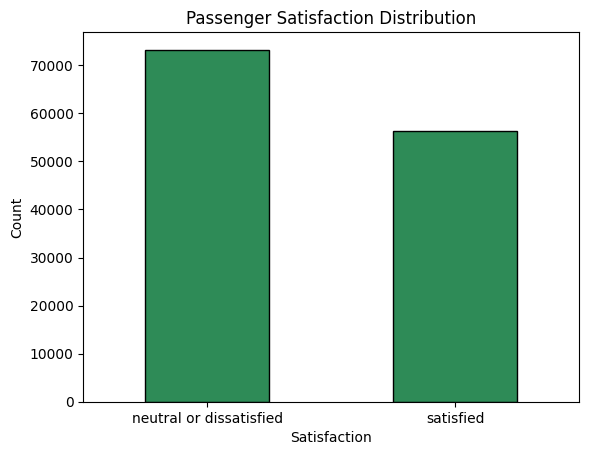

In [ ]:
data['satisfaction'].value_counts().plot(kind='bar',color = 'seagreen', edgecolor = 'black')
plt.xlabel('Satisfaction')
plt.xticks(rotation=0)
plt.title('Passenger Satisfaction Distribution')
plt.ylabel('Count')
plt.show()

Observation:

Passenger satisfaction is fairly balanced, but neutral or dissatisfied passengers are slightly higher in number than satisfied passengers, with a difference of 16,963 records. This suggests there is meaningful room for service and operational improvement.

2. Satisfaction vs class

In [ ]:
pd.crosstab(data['class'], data['satisfaction']) * 100

satisfaction,neutral or dissatisfied,satisfied
class,,
Business,1894000,4305000
Eco,4721500,1090200
Eco Plus,707000,231000


<Figure size 5000x1000 with 0 Axes>

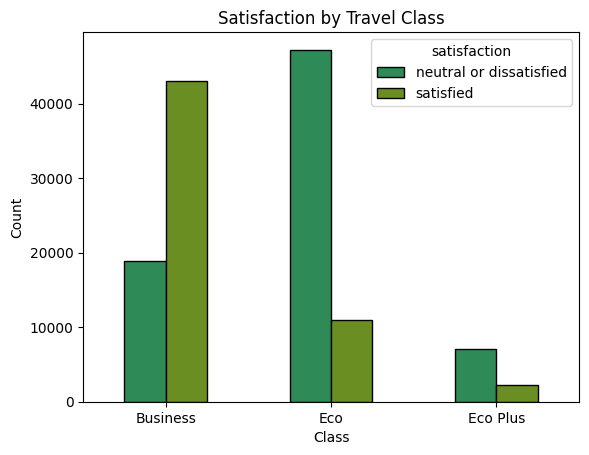

In [ ]:
plt.figure(figsize=(50, 10))
pd.crosstab(data['class'], data['satisfaction']).plot(kind='bar', color=['seagreen','olivedrab'], edgecolor = 'black')
plt.xlabel('Class')
plt.xticks(rotation=0)
plt.title('Satisfaction by Travel Class')
plt.ylabel('Count')
plt.show()

Observation:

Business class has the strongest satisfaction performance, with satisfied passengers clearly outnumbering neutral or dissatisfied passengers. In contrast, Economy and Economy Plus show higher dissatisfaction shares, indicating that passenger experience challenges are more concentrated in lower travel classes.

3. Satisfaction vs loyalty

In [ ]:
pd.crosstab(data['customer_type'], data['satisfaction']) * 100

satisfaction,neutral or dissatisfied,satisfied
customer_type,,
Loyal Customer,5519900,5057400
disloyal Customer,1802600,568800


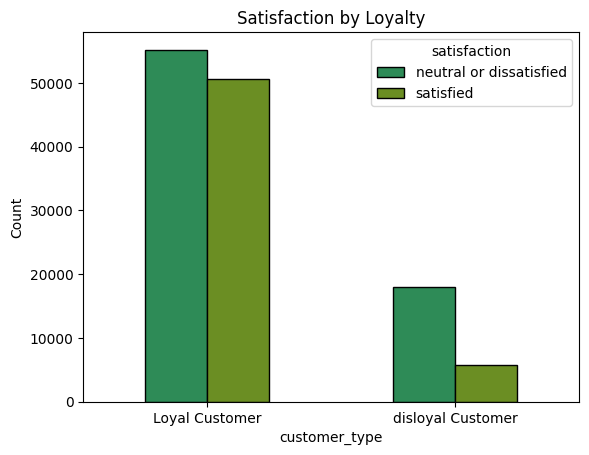

In [ ]:
pd.crosstab(data['customer_type'], data['satisfaction']).plot(kind='bar',color=['seagreen','olivedrab'], edgecolor = 'black')
plt.xticks(rotation = 0)
plt.title('Satisfaction by Loyalty')
plt.ylabel('Count')
plt.show()

Observation:

Disloyal customers and Loyal customers are substantially more likely to be neutral or dissatisfied.

**4. Satisfaction vs delay**

In [ ]:
data.groupby('satisfaction')[['departure_delay_in_minutes', 'arrival_delay_in_minutes']].mean().round(0)

,departure_delay_in_minutes,arrival_delay_in_minutes
satisfaction,,
neutral or dissatisfied,16.0,17.0
satisfied,12.0,13.0


Obervation:

Passengers who experienced dissatisfaction had, on average, around 4 more minutes of delay than satisfied passengers. Although the difference is not very large, it suggests that even relatively small delays may negatively affect customer perception, especially when combined with poor service ratings.

In [ ]:
pd.crosstab(data['delay_flag'], data['satisfaction'])

satisfaction,neutral or dissatisfied,satisfied
delay_flag,,
Delayed,41880,28256
On Time,31345,28006


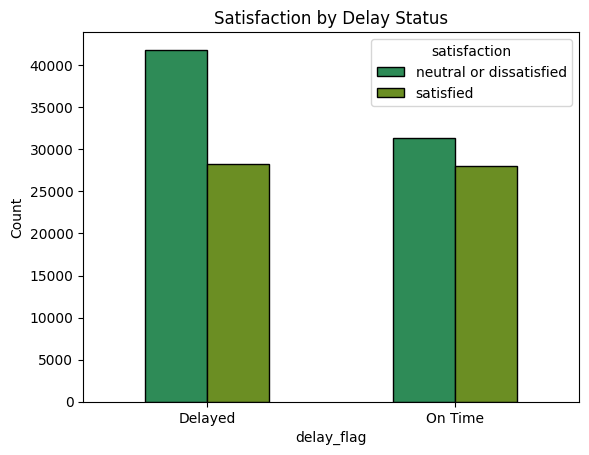

In [ ]:
pd.crosstab(data['delay_flag'], data['satisfaction']).plot(kind='bar', color=['seagreen','olivedrab'], edgecolor = 'black')
plt.xticks(rotation = 0)
plt.title('Satisfaction by Delay Status')
plt.ylabel('Count')
plt.show()

Observation:

Delayed flights are associated with a higher share of neutral or dissatisfied passengers compared with on-time flights. However, dissatisfaction is also present even among on-time passengers, which indicates that operational punctuality alone does not fully explain passenger experience and service quality must also be considered.

**5. Satisfaction vs average service rating**

In [ ]:
data.groupby('satisfaction')['avg_service_rating'].mean()

,avg_service_rating
satisfaction,
neutral or dissatisfied,2.954059
satisfied,3.615053


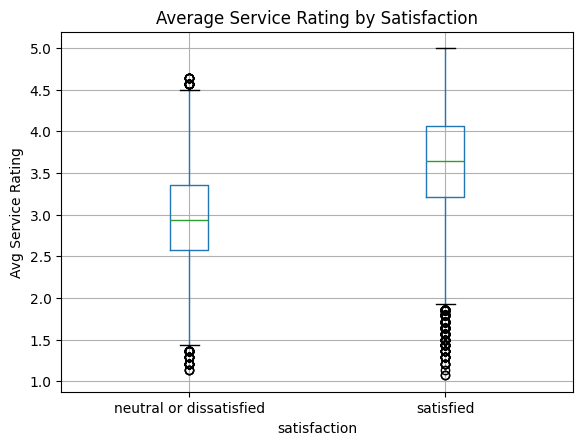

In [ ]:
data.boxplot(column='avg_service_rating', by='satisfaction')
plt.title('Average Service Rating by Satisfaction')
plt.suptitle('')
plt.ylabel('Avg Service Rating')
plt.show()

**6. Individual service ratings vs satisfaction**

In [ ]:
service_comparison = data.groupby('satisfaction')[service_cols].mean().T
service_comparison['gap'] = (
service_comparison['satisfied'] - service_comparison['neutral or dissatisfied']
)
service_comparison.sort_values('gap', ascending=False)

satisfaction,neutral or dissatisfied,satisfied,gap
online_boarding,2.658846,4.025648,1.366802
inflight_entertainment,2.892236,3.964345,1.072109
seat_comfort,3.038525,3.966176,0.927651
on-board_service,3.019570,3.856475,0.836905
leg_room_service,2.990495,3.820376,0.829881
cleanliness,2.932851,3.746134,0.813283
inflight_wifi_service,2.398470,3.158135,0.759665
checkin_service,3.043045,3.648786,0.605741
baggage_handling,3.374681,3.966638,0.591957
inflight_service,3.389662,3.971277,0.581615


Observaion:

Online boarding shows the strongest rating gap between satisfied and neutral/dissatisfied passengers, with a difference of 1.36 points. This makes it one of the most important service factors influencing overall passenger satisfaction. Other service attributes also show noticeable gaps, but online boarding stands out as the clearest differentiator.

**7. Satisfaction vs type of travel**

In [ ]:
pd.crosstab(data['type_of_travel'], data['satisfaction']) * 100

satisfaction,neutral or dissatisfied,satisfied
type_of_travel,,
Business travel,3723800,5220700
Personal Travel,3598700,405500


Observation:

Business travel passengers are more likely to report satisfaction, while personal travel passengers are much more likely to be neutral or dissatisfied. This indicates that travel purpose strongly influences customer experience, possibly due to differences in service expectations, class mix, or travel urgency.





**8. Satisfaction vs age group**

In [ ]:
pd.crosstab(data['age_group'], data['satisfaction']) * 100

satisfaction,neutral or dissatisfied,satisfied
age_group,,
0-18,908900,194300
19-30,1912500,1059700
31-45,2118000,2018500
46-60,1589300,2145800
60+,793800,207900


Observation:

Satisfaction varies noticeably across age groups. Passengers aged 0–18 and 46–60 show stronger satisfaction levels, while the 19–30 and 60+ groups show relatively higher dissatisfaction. This suggests that age-based differences in expectations or travel experience may influence passenger satisfaction.





**9. Satisfaction vs distance bucket**

In [ ]:
pd.crosstab(data['distance_bucket'], data['satisfaction']) * 100

satisfaction,neutral or dissatisfied,satisfied
distance_bucket,,
Short Haul,5013200,2476200
Medium Haul,1851400,1879400
Long Haul,457900,1270600


Observation:

Short-haul passengers are more likely to be neutral or dissatisfied, while long-haul passengers show much stronger satisfaction levels. Medium-haul travel appears relatively balanced. This suggests that passengers may perceive more value or better service quality on longer journeys compared with short-haul flights.


In [ ]:
data.to_csv("airline_passenger_cleaned.csv", index=False)